In [1]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn.functional as F

In [2]:
# === CONFIG ===
INPUT_DIR = "/home/HardDisk/Satang/thesis_proj/New_30/10/split_output_8"
CHUNK_SIZE = 22
NUM_FEATURES = 8
NUM_EPOCHS = 50
BATCH_SIZE = 32
K_FOLDS = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# === HELPERS ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

def compute_class_weights(labels, device):
    counter = Counter(labels)
    total = sum(counter.values())
    weights = [np.log(total / (counter[i] + 1)) for i in range(len(counter))]
    return torch.tensor(weights, dtype=torch.float).to(device)

def print_model_info(model):
    print("Model Architecture:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

def plot_loss_curve(train_losses, val_losses):
    epochs = range(len(train_losses))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_accuracy_curve(train_acc, val_acc):
    epochs = range(len(train_acc))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_acc, label='Train Accuracy', color='green')
    plt.plot(epochs, val_acc, label='Val Accuracy', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# === DATASET CLASS ===
class MultiStreamDataset(Dataset):
    def __init__(self, data, labels, label_encoder, augment=False):
        self.data = data
        self.labels = label_encoder.transform(labels)
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def augment_stream(self, stream):
        jitter = np.random.normal(0, 0.01, stream.shape)
        scale = np.random.normal(1.0, 0.05, stream.shape)
        return stream * scale + jitter

    def __getitem__(self, idx):
        sample = self.data[idx]
        streams = [sample[:, i].reshape(1, -1).astype(np.float32) for i in range(sample.shape[1])]
        if self.augment:
            streams = [self.augment_stream(s.copy()) for s in streams]
        streams = [torch.tensor(s).float() for s in streams]
        label = torch.tensor(self.labels[idx])
        return streams, label

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)


class MultiStreamCNN(nn.Module):
    def __init__(self, input_length=CHUNK_SIZE, num_classes=12):
        super(MultiStreamCNN, self).__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(1, 32),
                ResidualBlock(32, 64),
                nn.MaxPool1d(kernel_size=2),

                ResidualBlock(64, 128),
                ResidualBlock(128, 256, dilation=2),
                nn.Dropout(0.3),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(8)
        ])

        self.fc = nn.Sequential(
            nn.Linear(256 * 8, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, streams):  # streams: list of 8 tensors (B, 1, L)
        features = [self.streams[i](streams[i]) for i in range(8)]
        x = torch.cat(features, dim=1)
        return self.fc(x)

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

def apply_smote_on_training(X_chunks, y_labels, train_indices, chunk_size, num_features):
    # === Encode labels for SMOTE
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_labels)

    # === Get training data only
    X_train = X_chunks[train_indices]
    y_train = y_encoded[train_indices]

    # === Decode to strings (to preserve label names)
    y_train_str = label_encoder.inverse_transform(y_train)

    # === Re-encode using temp encoder for SMOTE (to keep class names aligned)
    smote_encoder = LabelEncoder()
    y_train_encoded = smote_encoder.fit_transform(y_train_str)

    # === Flatten for SMOTE
    X_train_flat = X_train.reshape(X_train.shape[0], -1)

    # === Apply SMOTE
    X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train_encoded)

    # === Reshape back to original format
    X_train_balanced = X_resampled.reshape(-1, chunk_size, num_features)
    y_res_str = smote_encoder.inverse_transform(y_resampled)

    return X_train_balanced, y_res_str, label_encoder

In [ ]:
# === 1. Load full dataset and define shared train/val sets ===
X_chunks, y_labels = [], []
for class_name in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in sorted(os.listdir(class_path)):
        if fname.endswith(".csv"):
            fpath = os.path.join(class_path, fname)
            chunk = pd.read_csv(fpath, header=None).values
            if chunk.shape == (CHUNK_SIZE, NUM_FEATURES):
                X_chunks.append(chunk)
                y_labels.append(class_name)

X_chunks = np.array(X_chunks)
y_labels = np.array(y_labels)

# === Global label encoder (shared by all models)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# === Split indices once
total_size = len(X_chunks)
val_size = int(0.3 * total_size)
train_size = total_size - val_size
train_indices, val_indices = random_split(range(total_size), [train_size, val_size], generator=torch.Generator().manual_seed(42))

# === Apply SMOTE once to training data only
X_train_balanced, y_train_str, _ = apply_smote_on_training(
    X_chunks, y_labels, train_indices.indices, CHUNK_SIZE, NUM_FEATURES
)

# === Validation set (raw, unbalanced)
X_val = X_chunks[val_indices.indices]
y_val = label_encoder.transform(y_labels[val_indices.indices])
y_val_str = label_encoder.inverse_transform(y_val)

# === Create datasets (shared)
train_dataset = MultiStreamDataset(X_train_balanced, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val, y_val_str, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# === Class weights
class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)


In [8]:
# === LOAD ORIGINAL DATA ===
X_chunks, y_labels = [], []
for class_name in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in sorted(os.listdir(class_path)):
        if fname.endswith(".csv"):
            fpath = os.path.join(class_path, fname)
            chunk = pd.read_csv(fpath, header=None).values
            if chunk.shape == (CHUNK_SIZE, NUM_FEATURES):
                X_chunks.append(chunk)
                y_labels.append(class_name)

X_chunks = np.array(X_chunks)
y_labels = np.array(y_labels)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)


In [9]:
def train_model(model, train_loader, val_loader, device, epochs=50, lr=0.001, class_weights=None,
                patience=10, min_delta=0.001):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1,weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)
            outputs = model(streams)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)
                outputs = model(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss:.4f} - Val Loss: {val_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        if val_loss + min_delta < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_accuracies, val_accuracies, train_losses, val_losses



--- Fold 1 / 5 ---


Model Architecture:
MultiStreamCNN(
  (streams): ModuleList(
    (0-7): 8 x Sequential(
      (0): ResidualBlock(
        (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      )
      (1): ResidualBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      )
      (2): MaxPool1d(k

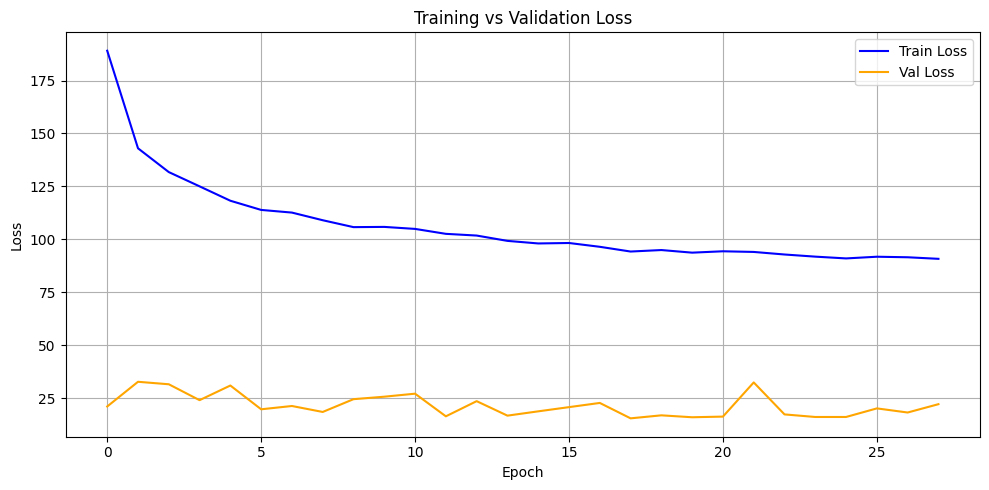

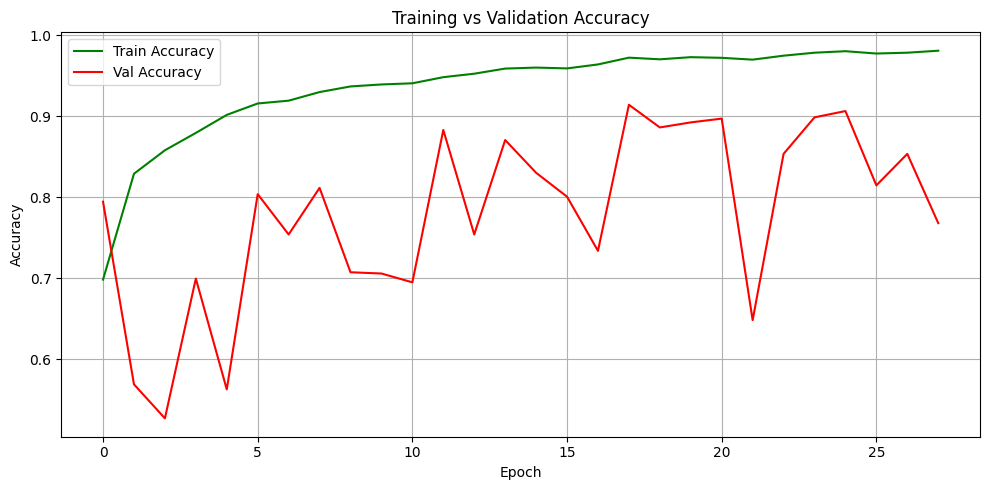


--- Fold 2 / 5 ---
Model Architecture:
MultiStreamCNN(
  (streams): ModuleList(
    (0-7): 8 x Sequential(
      (0): ResidualBlock(
        (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      )
      (1): ResidualBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      )
  

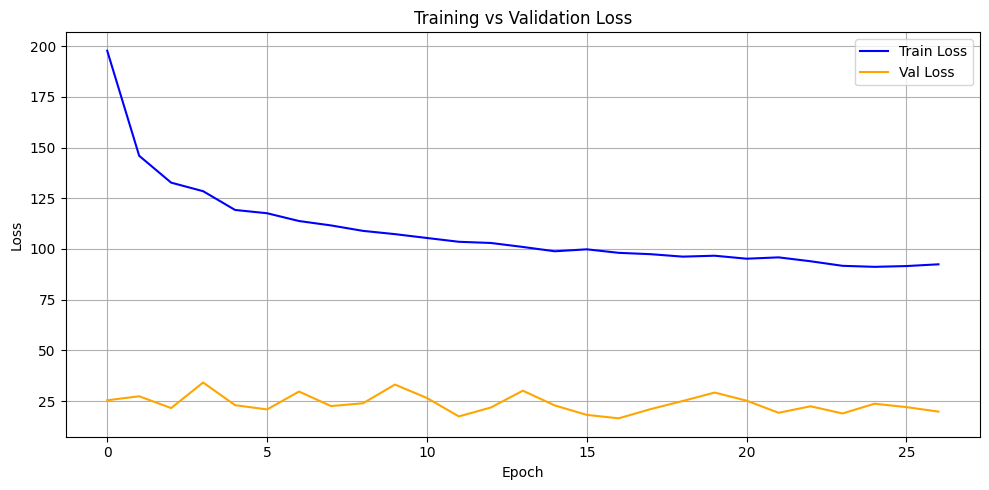

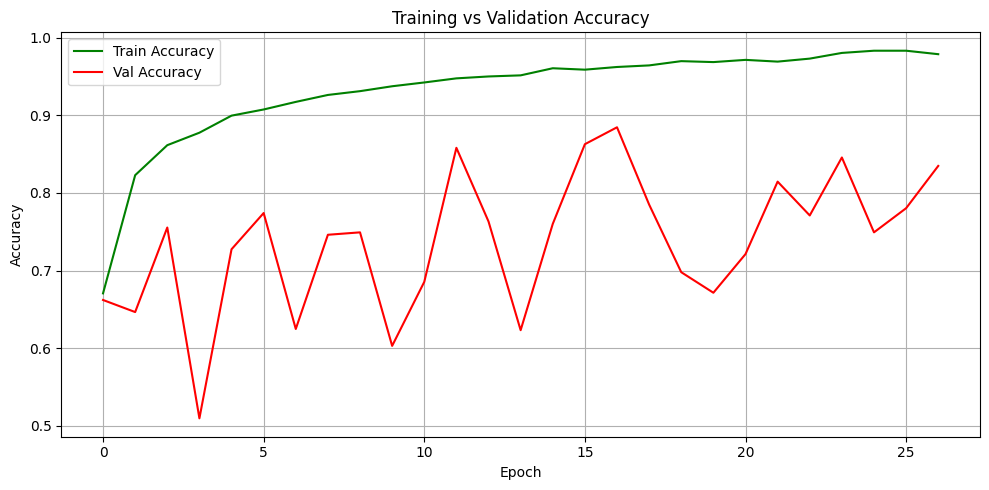


--- Fold 3 / 5 ---
Model Architecture:
MultiStreamCNN(
  (streams): ModuleList(
    (0-7): 8 x Sequential(
      (0): ResidualBlock(
        (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      )
      (1): ResidualBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      )
  

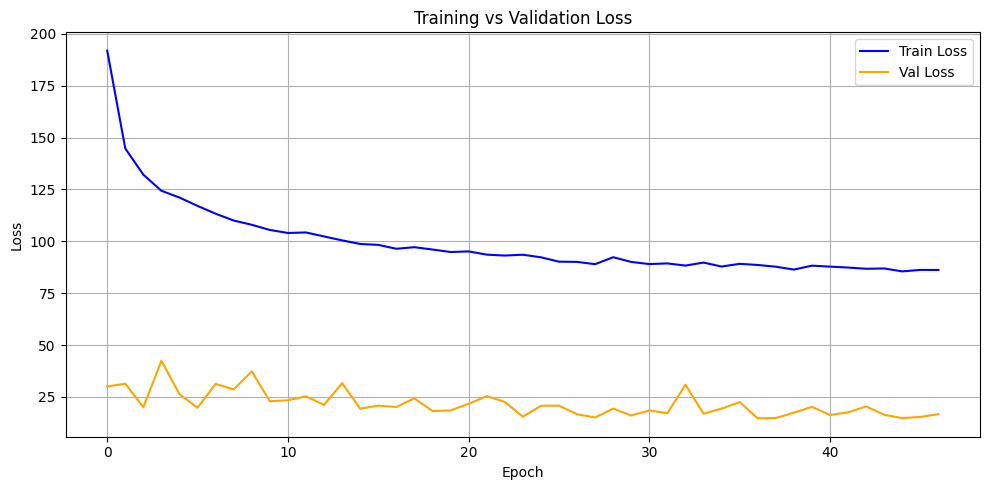

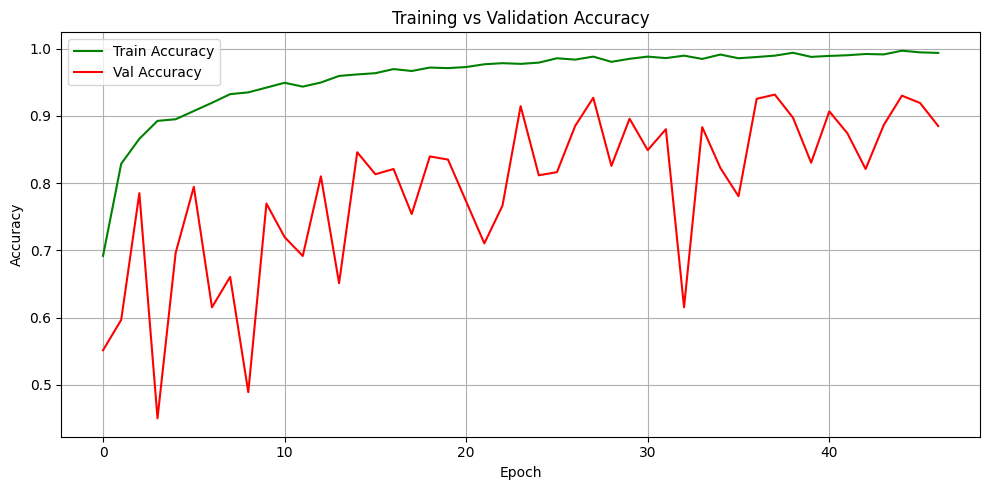


--- Fold 4 / 5 ---
Model Architecture:
MultiStreamCNN(
  (streams): ModuleList(
    (0-7): 8 x Sequential(
      (0): ResidualBlock(
        (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      )
      (1): ResidualBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      )
  

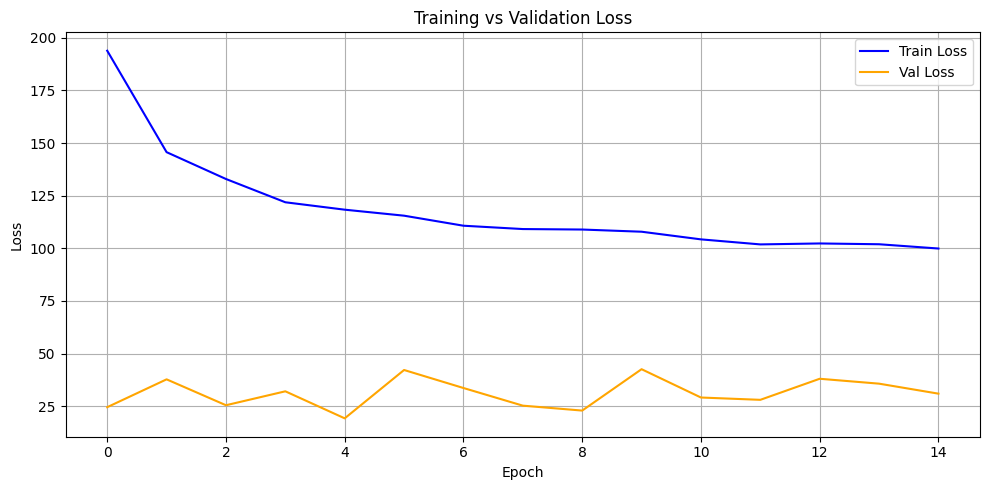

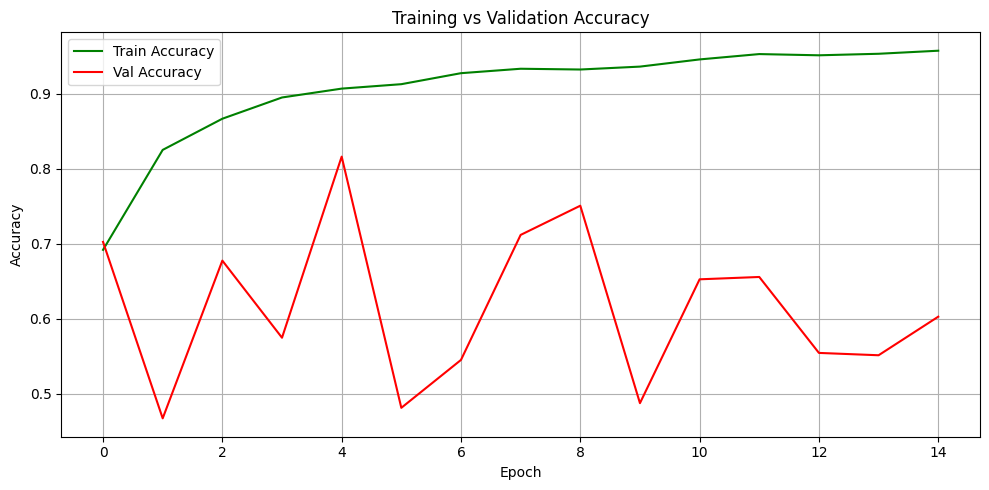


--- Fold 5 / 5 ---
Model Architecture:
MultiStreamCNN(
  (streams): ModuleList(
    (0-7): 8 x Sequential(
      (0): ResidualBlock(
        (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      )
      (1): ResidualBlock(
        (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      )
  

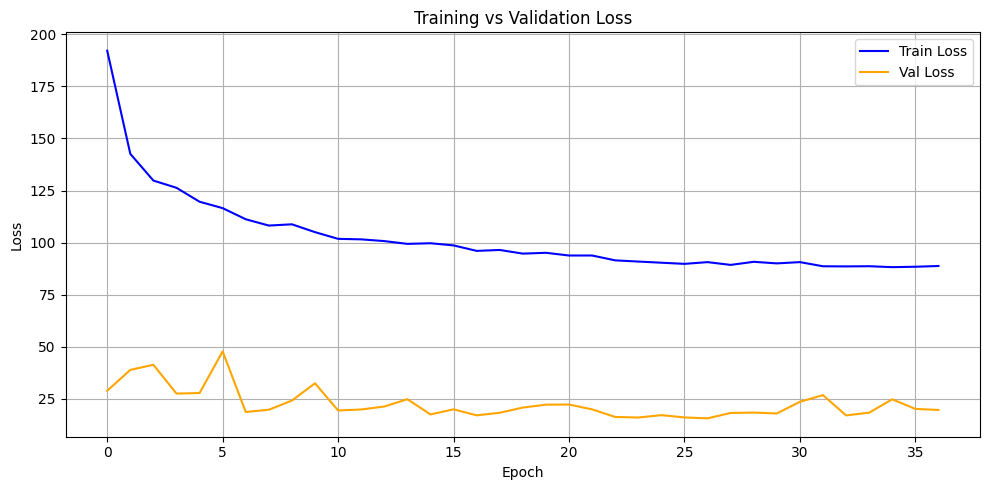

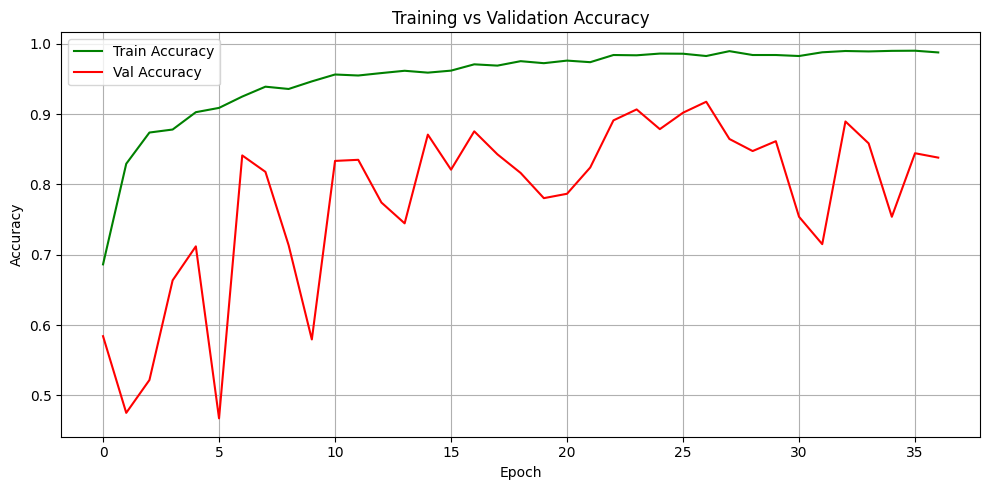

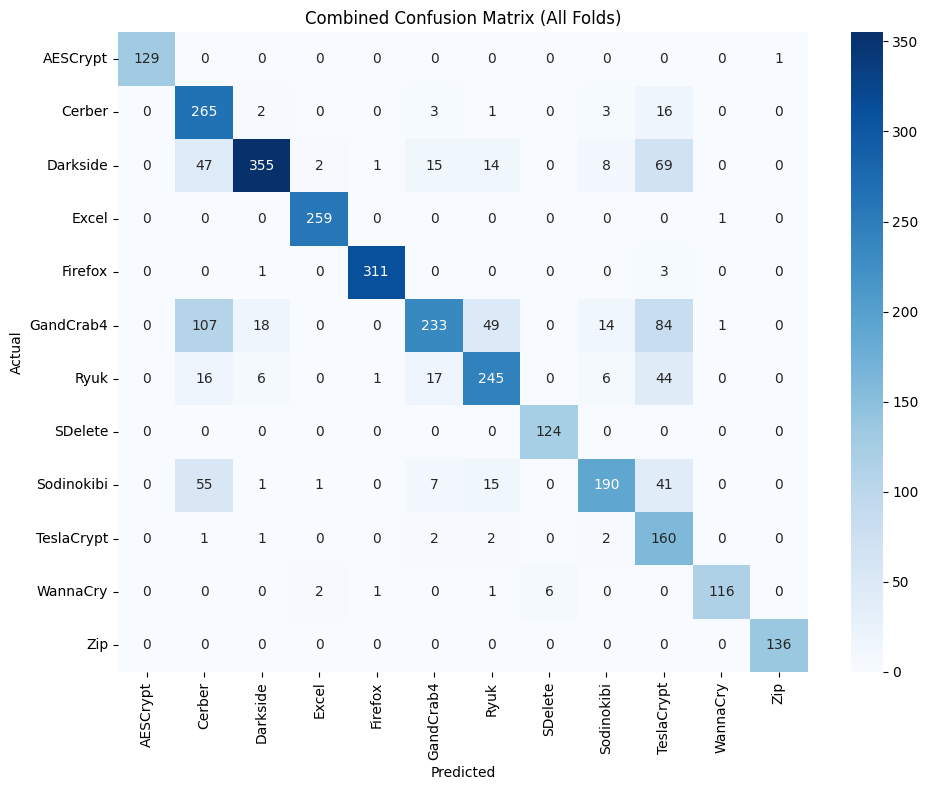


Final Combined Classification Report (All Folds):

              precision    recall  f1-score   support

    AESCrypt       1.00      0.99      1.00       130
      Cerber       0.54      0.91      0.68       290
    Darkside       0.92      0.69      0.79       511
       Excel       0.98      1.00      0.99       260
     Firefox       0.99      0.99      0.99       315
   GandCrab4       0.84      0.46      0.60       506
        Ryuk       0.75      0.73      0.74       335
     SDelete       0.95      1.00      0.98       124
  Sodinokibi       0.85      0.61      0.71       310
  TeslaCrypt       0.38      0.95      0.55       168
    WannaCry       0.98      0.92      0.95       126
         Zip       0.99      1.00      1.00       136

    accuracy                           0.79      3211
   macro avg       0.85      0.86      0.83      3211
weighted avg       0.84      0.79      0.79      3211


Average Final Training Accuracy: 0.9797
Average Final Validation Accuracy: 0.785

In [10]:


# === K-FOLD TRAINING LOOP ===
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_preds_global, all_labels_global = [], []
all_train_acc, all_val_acc = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded)):
    print(f"\n--- Fold {fold + 1} / {K_FOLDS} ---")
    X_train, y_train = X_scaled[train_idx], y_encoded[train_idx]
    X_val, y_val     = X_scaled[val_idx],   y_encoded[val_idx]

    X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)
    X_train_final = X_train_res.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
    y_train_final = label_encoder.inverse_transform(y_train_res)
    X_val_final = X_val.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
    y_val_final = label_encoder.inverse_transform(y_val)

    train_dataset = MultiStreamDataset(X_train_final, y_train_final, label_encoder, augment=True)
    val_dataset   = MultiStreamDataset(X_val_final,   y_val_final,   label_encoder, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=collate_fn)

    model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
    print_model_info(model)

    class_weights_tensor = compute_class_weights(train_dataset.labels, device)
    train_accs, val_accs, train_losses, val_losses = train_model(
        model, train_loader, val_loader, device, epochs=NUM_EPOCHS, class_weights=class_weights_tensor
    )

    all_train_acc.append(train_accs[-1])
    all_val_acc.append(val_accs[-1])
    plot_loss_curve(train_losses, val_losses)
    plot_accuracy_curve(train_accs, val_accs)

    model.eval()
    with torch.no_grad():
        for streams, labels in val_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)
            outputs = model(streams)
            preds = torch.argmax(outputs, dim=1)
            all_preds_global.extend(preds.cpu().numpy())
            all_labels_global.extend(labels.cpu().numpy())

# === FINAL REPORT ===
cm = confusion_matrix(all_labels_global, all_preds_global)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Combined Confusion Matrix (All Folds)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Combined Classification Report (All Folds):\n")
print(classification_report(all_labels_global, all_preds_global, target_names=label_encoder.classes_))
print(f"\nAverage Final Training Accuracy: {np.mean(all_train_acc):.4f}")
print(f"Average Final Validation Accuracy: {np.mean(all_val_acc):.4f}")



In [11]:
from sklearn.model_selection import train_test_split
# === 1. Load full dataset and define shared train/val/test sets ===
X_chunks, y_labels = [], []
for class_name in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in sorted(os.listdir(class_path)):
        if fname.endswith(".csv"):
            fpath = os.path.join(class_path, fname)
            chunk = pd.read_csv(fpath, header=None).values
            if chunk.shape == (CHUNK_SIZE, NUM_FEATURES):
                X_chunks.append(chunk)
                y_labels.append(class_name)

X_chunks = np.array(X_chunks)
y_labels = np.array(y_labels)

# === 2. Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_chunks, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

# Second split: 15% val, 15% test (from that 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# === 4. Apply SMOTE on training only
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train)
X_train_bal = X_resampled.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
y_train_str = label_encoder.inverse_transform(y_resampled)
y_val_str = label_encoder.inverse_transform(y_val)

# === 5. Create datasets
train_dataset = MultiStreamDataset(X_train_bal, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val, y_val_str, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# === Class weights (for training only)
class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)



/home/ea301b/anaconda3/envs/dl_satang/lib/python3.11/site-packages/torch_lr_finder/lr_finder.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm



=== 🧠 Retraining Teacher Model ===
🔍 Finding optimal learning rate...


100%|██████████| 100/100 [00:06<00:00, 16.42it/s]


Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 5.46E-03


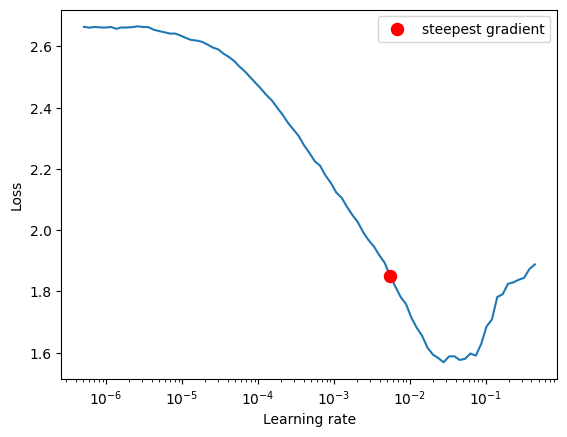

Epoch 1/50 - Train Loss: 209.6340 - Val Loss: 23.5493 - Train Acc: 0.5221 - Val Acc: 0.4917
Epoch 2/50 - Train Loss: 154.0379 - Val Loss: 21.9728 - Train Acc: 0.7365 - Val Acc: 0.6017
Epoch 3/50 - Train Loss: 144.2523 - Val Loss: 23.3341 - Train Acc: 0.7665 - Val Acc: 0.5954
Epoch 4/50 - Train Loss: 137.6848 - Val Loss: 24.3348 - Train Acc: 0.7779 - Val Acc: 0.5539
Epoch 5/50 - Train Loss: 130.4219 - Val Loss: 18.4835 - Train Acc: 0.8061 - Val Acc: 0.6763
Epoch 6/50 - Train Loss: 127.2084 - Val Loss: 18.0837 - Train Acc: 0.8224 - Val Acc: 0.6805
Epoch 7/50 - Train Loss: 123.9242 - Val Loss: 21.2102 - Train Acc: 0.8310 - Val Acc: 0.6452
Epoch 8/50 - Train Loss: 119.4744 - Val Loss: 22.7473 - Train Acc: 0.8473 - Val Acc: 0.6473
Epoch 9/50 - Train Loss: 114.7549 - Val Loss: 23.6420 - Train Acc: 0.8631 - Val Acc: 0.6162
Epoch 10/50 - Train Loss: 113.2481 - Val Loss: 15.4926 - Train Acc: 0.8708 - Val Acc: 0.7739
Epoch 11/50 - Train Loss: 113.5172 - Val Loss: 24.0623 - Train Acc: 0.8689 - Va

In [12]:
from torch_lr_finder import LRFinder

print("\n=== 🧠 Retraining Teacher Model ===")

# === Initialize Teacher Model
final_teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)

# === 🔍 Learning Rate Finder
print("🔍 Finding optimal learning rate...")
optimizer = torch.optim.Adam(final_teacher.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lr_finder = LRFinder(final_teacher, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=100)
lr_finder.plot()
lr_finder.reset()

# === Use best LR after checking the LR plot
BEST_LR = 0.005  # Replace this based on your LR curve

# === Train Teacher
train_accs, val_accs, train_losses, val_losses = train_model(
    final_teacher,
    train_loader,
    val_loader=val_loader,
    device=device,
    epochs=NUM_EPOCHS,
    class_weights=class_weights_tensor,
    lr=BEST_LR
)

# === Save model
torch.save(final_teacher.state_dict(), "teacher_full.pth")
print("✅ Final teacher model saved as 'teacher_smote_train_only.pth'")

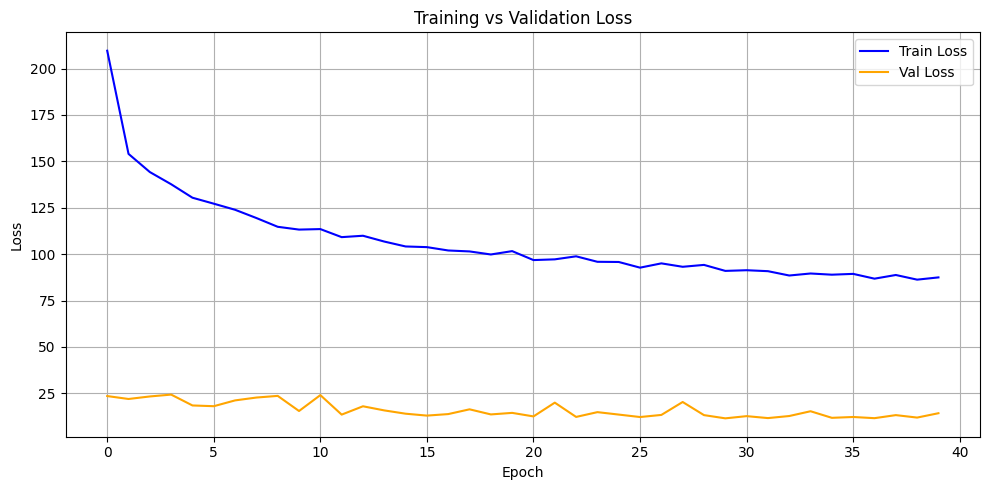

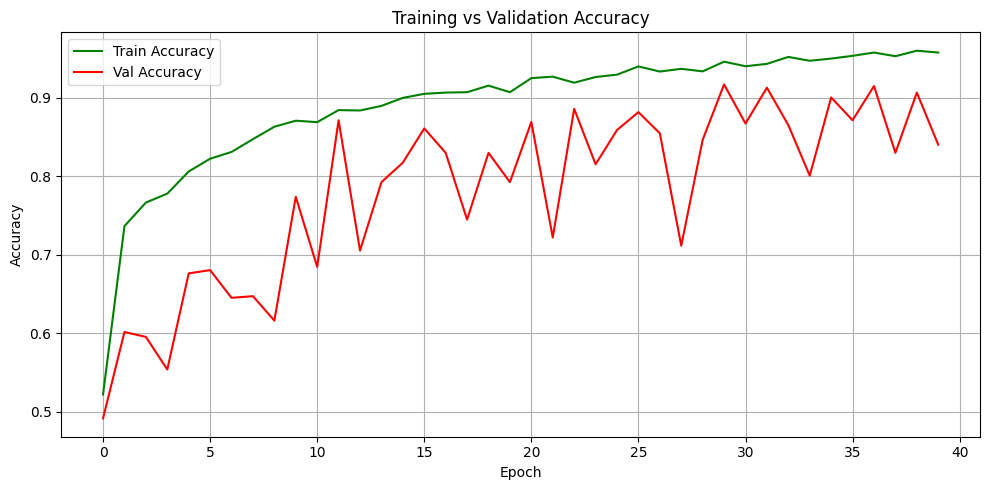

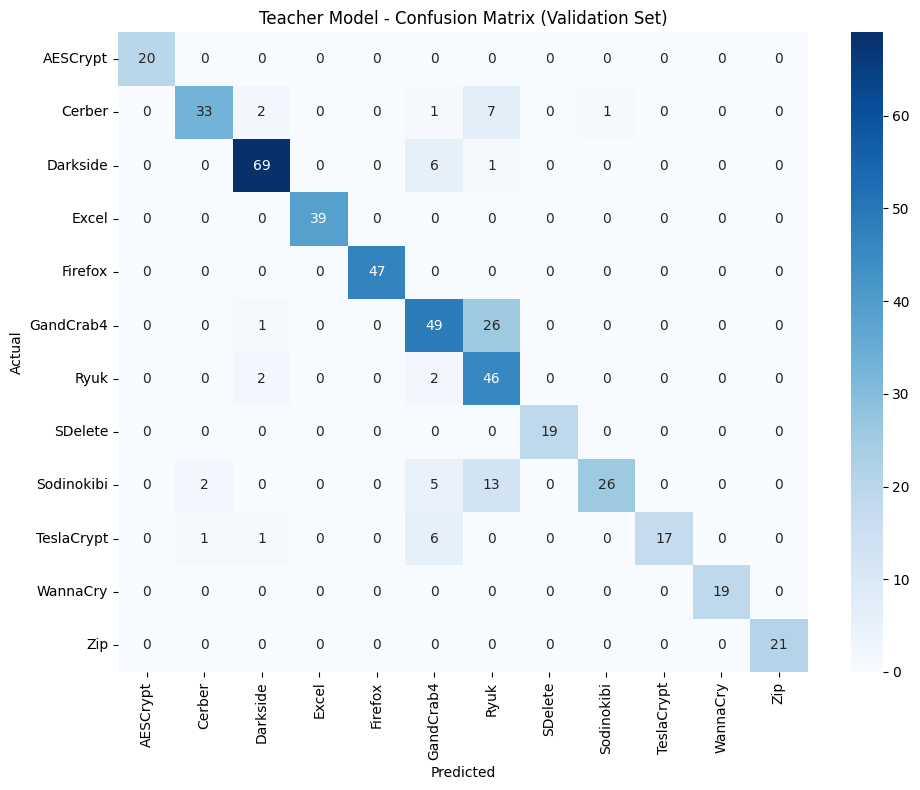


Final Classification Report (Teacher):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        20
      Cerber       0.92      0.75      0.82        44
    Darkside       0.92      0.91      0.91        76
       Excel       1.00      1.00      1.00        39
     Firefox       1.00      1.00      1.00        47
   GandCrab4       0.71      0.64      0.68        76
        Ryuk       0.49      0.92      0.64        50
     SDelete       1.00      1.00      1.00        19
  Sodinokibi       0.96      0.57      0.71        46
  TeslaCrypt       1.00      0.68      0.81        25
    WannaCry       1.00      1.00      1.00        19
         Zip       1.00      1.00      1.00        21

    accuracy                           0.84       482
   macro avg       0.92      0.87      0.88       482
weighted avg       0.88      0.84      0.85       482


Final Training Accuracy: 0.9576
Final Validation Accuracy: 0.8402


In [13]:
# === 🔍 Plot training curves
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === 📊 Evaluate on validation set (same used during training)
final_teacher.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = final_teacher(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix & Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Teacher Model - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Teacher):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

🧠 Multi-class AUC (macro): 0.9869


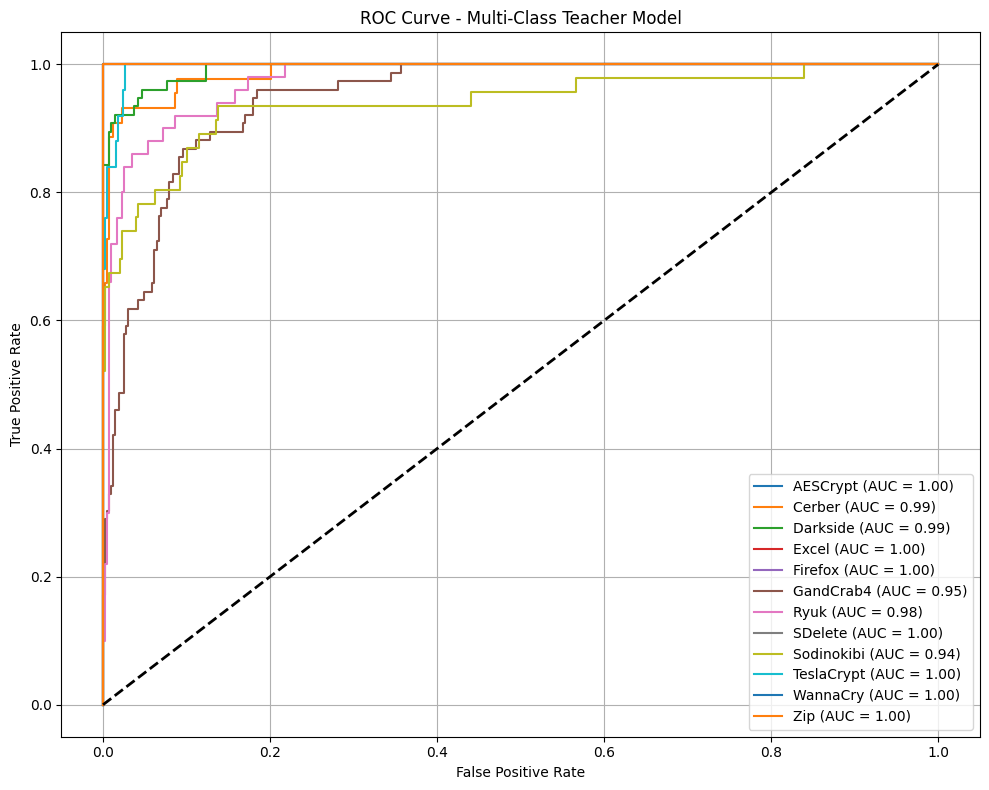

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# === 1. Get predictions on validation set ===
final_teacher.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.cpu().numpy()
        outputs = final_teacher(streams)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        
        y_probs.extend(probs)
        y_true.extend(labels)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# === 2. Binarize labels for ROC AUC ===
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

# === 3. Compute AUC score (macro-average) ===
auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
print(f"🧠 Multi-class AUC (macro): {auc_macro:.4f}")

# === 4. Plot ROC curves per class ===
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Teacher Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
# import shap

# class SHAPWrapper(torch.nn.Module):
#     def __init__(self, model):
#         super().__init__()
#         self.model = model

#     def forward(self, *inputs):
#         return self.model(list(inputs))
    
# # === 1. Load your trained model ===
# model = MultiStreamCNN(input_length=37)
# model.load_state_dict(torch.load("/home/HardDisk/Satang/thesis_proj/New_45/10/teacher_full.pth"))
# model.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # === 2. Get a validation sample batch (small subset is enough for SHAP) ===
# # Assume val_loader gives (streams, labels) and streams = list of 8 tensors
# val_iter = iter(val_loader)
# streams, labels = next(val_iter)

# # Use first 50 samples, convert to device, set requires_grad for SHAP
# sample_streams = [s[:50].to(device).requires_grad_() for s in streams]

# # === 3. Create SHAP explainer for the model ===
# wrapped_model = SHAPWrapper(model)
# explainer = shap.DeepExplainer(wrapped_model, sample_streams)

# # === 4. Compute SHAP values ===
# shap_values = explainer.shap_values(sample_streams)  # List: [num_classes][num_streams]

# # === 5. Aggregate SHAP values globally across all classes and samples ===
# # Option A: Pick one class to analyze (e.g., class 0)
# class_idx = 0

# # Option B: Average across all classes (closer to Random Forest idea)
# # We'll use Option B
# num_classes = len(shap_values)
# num_streams = len(sample_streams)

# avg_importance_per_stream = []

# for i in range(num_streams):
#     stream_total = 0.0
#     for c in range(num_classes):
#         shap_stream = shap_values[c][i]  # shape: (samples, timesteps)
#         stream_total += np.abs(shap_stream).mean()
#     avg_importance_per_stream.append(stream_total / num_classes)

# # === 6. Plot global feature importance ===
# stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "Var_H_write", "SLR_write", "SLR_read"][:num_streams]

# plt.figure(figsize=(10, 5))
# plt.bar(stream_names, avg_importance_per_stream)
# plt.ylabel("Mean |SHAP value|")
# plt.title("Global SHAP Feature Importance per Stream")
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()


In [16]:
# import shap
# import numpy as np

# # === 1. Pick a class (or average across classes)
# class_idx = 0  # You can change this to any class index
# num_streams = len(sample_streams)
# sequence_length = sample_streams[0].shape[2]

# # === 2. Convert SHAP and input data to NumPy arrays
# shap_numpy = [s.cpu().detach().numpy().squeeze() for s in shap_values[class_idx]]  # List of (samples, time)
# input_numpy = [s.cpu().detach().numpy().squeeze() for s in sample_streams]         # Same shape

# # === 3. Stack all streams into a single matrix for SHAP
# # Shape: (samples, streams * time)
# shap_matrix = np.hstack(shap_numpy)
# input_matrix = np.hstack(input_numpy)

# # Create feature names: e.g., T_write_0, T_write_1, ..., SLR_read_31
# stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "Var_H_write", "SLR_write", "SLR_read"][:num_streams]
# feature_names = [f"{stream}_{t}" for stream in stream_names for t in range(sequence_length)]

# # === 4. Plot the summary (beeswarm)
# shap.summary_plot(shap_matrix, input_matrix, feature_names=feature_names)


In [17]:
class StudentCNN(nn.Module):
    def __init__(self, input_length=32, num_classes=12):
        super(StudentCNN, self).__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 8, kernel_size=3, padding=1),
                nn.BatchNorm1d(8),
                nn.GELU(),
                nn.Conv1d(8, 16, kernel_size=3, padding=1),
                nn.BatchNorm1d(16),
                nn.GELU(),
                nn.Conv1d(16, 32, kernel_size=3, padding=1),
                nn.BatchNorm1d(32),
                nn.GELU(),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(8)
        ])

        self.fc = nn.Sequential(
            nn.Linear(8 * 32, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, streams):
        features = [self.streams[i](streams[i]) for i in range(8)]
        x = torch.cat(features, dim=1)
        return self.fc(x)


In [18]:
import torch.nn.functional as F
def distillation_loss(student_logits, teacher_logits, true_labels, T=3.0, alpha=0.5, criterion=None):
    # Hard loss (true labels)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    hard_loss = criterion(student_logits, true_labels)

    # Soft loss (distillation)
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

    return alpha * hard_loss + (1 - alpha) * soft_loss

In [19]:
def train_distilled(student, teacher, train_loader, val_loader, device,
                    epochs=50, lr=0.0005, class_weights=None, T=4.0, alpha=0.6):

    teacher.eval()
    student.to(device)
    teacher.to(device)

    optimizer = optim.Adam(student.parameters(), lr=lr)

    # Optional: class weights (if imbalanced)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            # Move data to the right device
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            # Teacher output (frozen)
            with torch.no_grad():
                teacher_outputs = teacher(streams)

            # Student output
            student_outputs = student(streams)

            # KD Loss
            loss = distillation_loss(student_outputs, teacher_outputs, labels, T=T, alpha=alpha, criterion=criterion)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (student_outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)
                outputs = student(streams)

                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Distill] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

    return train_accuracies, val_accuracies, train_losses, val_losses


/tmp/ipykernel_287094/3573776841.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))


[Distill] Epoch 01/50 - Loss: 140.1783 - Train Acc: 0.6515 - Val Acc: 0.6473
[Distill] Epoch 02/50 - Loss: 94.4022 - Train Acc: 0.7581 - Val Acc: 0.6846
[Distill] Epoch 03/50 - Loss: 83.4685 - Train Acc: 0.7919 - Val Acc: 0.7407
[Distill] Epoch 04/50 - Loss: 76.5021 - Train Acc: 0.8194 - Val Acc: 0.7863
[Distill] Epoch 05/50 - Loss: 70.6799 - Train Acc: 0.8336 - Val Acc: 0.7905
[Distill] Epoch 06/50 - Loss: 66.8005 - Train Acc: 0.8515 - Val Acc: 0.7448
[Distill] Epoch 07/50 - Loss: 63.9398 - Train Acc: 0.8648 - Val Acc: 0.7739
[Distill] Epoch 08/50 - Loss: 61.2915 - Train Acc: 0.8645 - Val Acc: 0.7842
[Distill] Epoch 09/50 - Loss: 59.8237 - Train Acc: 0.8736 - Val Acc: 0.7593
[Distill] Epoch 10/50 - Loss: 57.9428 - Train Acc: 0.8748 - Val Acc: 0.8112
[Distill] Epoch 11/50 - Loss: 55.3810 - Train Acc: 0.8866 - Val Acc: 0.7759
[Distill] Epoch 12/50 - Loss: 54.8795 - Train Acc: 0.8836 - Val Acc: 0.7759
[Distill] Epoch 13/50 - Loss: 53.3370 - Train Acc: 0.8939 - Val Acc: 0.7075
[Distill] E

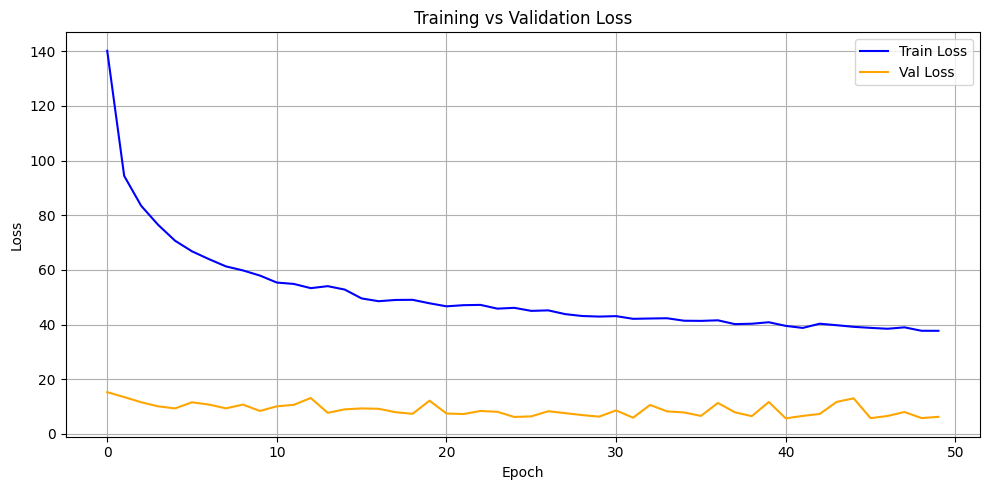

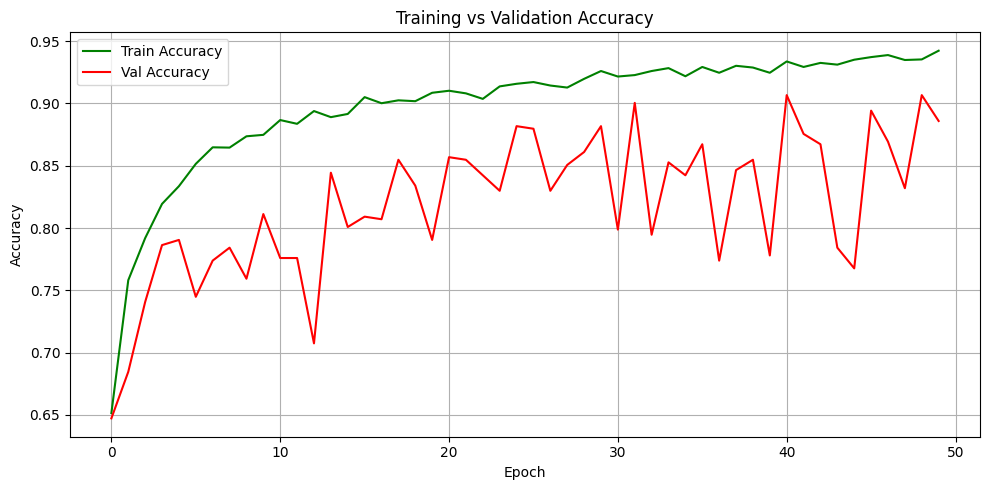

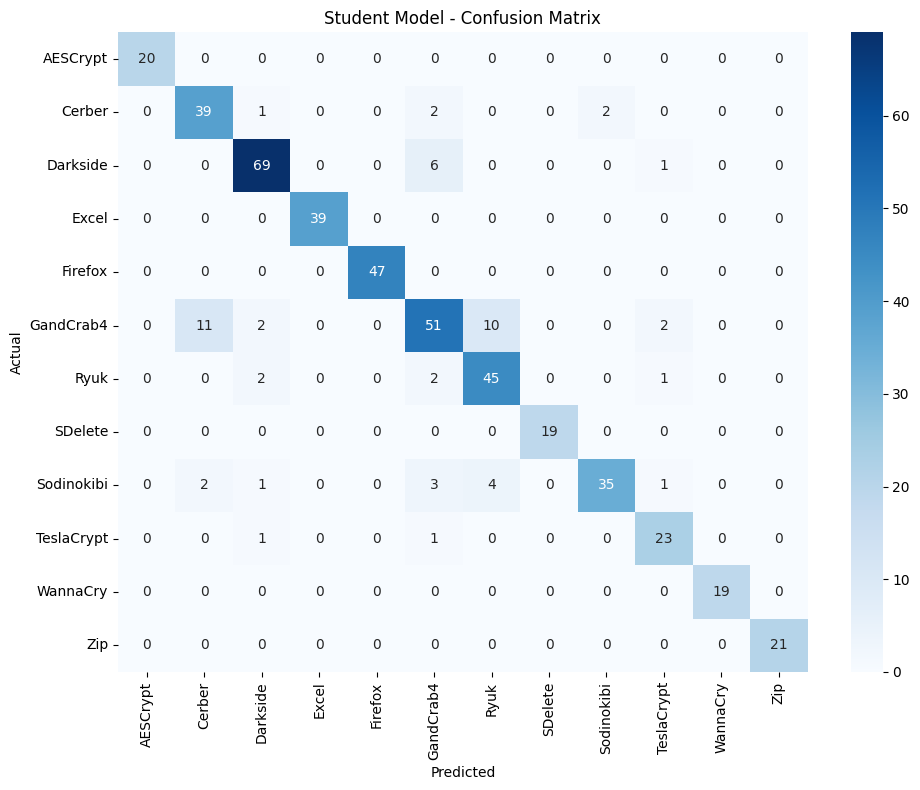


Final Classification Report (Student):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        20
      Cerber       0.75      0.89      0.81        44
    Darkside       0.91      0.91      0.91        76
       Excel       1.00      1.00      1.00        39
     Firefox       1.00      1.00      1.00        47
   GandCrab4       0.78      0.67      0.72        76
        Ryuk       0.76      0.90      0.83        50
     SDelete       1.00      1.00      1.00        19
  Sodinokibi       0.95      0.76      0.84        46
  TeslaCrypt       0.82      0.92      0.87        25
    WannaCry       1.00      1.00      1.00        19
         Zip       1.00      1.00      1.00        21

    accuracy                           0.89       482
   macro avg       0.91      0.92      0.92       482
weighted avg       0.89      0.89      0.88       482


Final Training Accuracy: 0.9423
Final Validation Accuracy: 0.8859


In [20]:
# === Load frozen teacher
teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))
teacher.to(device)
teacher.eval()

# === Train student with KD
student = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
train_accs, val_accs, train_losses, val_losses = train_distilled(
    student, teacher, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=0.001, class_weights=class_weights_tensor,
    T=3.0, alpha=0.5
)

# === Plot
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === Evaluate
student.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Student Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Student):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))
print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")


In [21]:
def train_student_baseline(student, train_loader, val_loader, device,
                           epochs=50, lr=0.0005, class_weights=None):

    student.to(device)
    optimizer = optim.Adam(student.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            outputs = student(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)
                outputs = student(streams)

                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Baseline] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

    return train_accuracies, val_accuracies, train_losses, val_losses

In [22]:
# === BASELINE STUDENT TRAINING (No KD) ===
student_baseline = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))

train_accs_b, val_accs_b, train_losses_b, val_losses_b = train_student_baseline(
    student_baseline, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=0.001, class_weights=class_weights_tensor
)
# === Save model
torch.save(student_baseline.state_dict(), "student_baseline.pth")
print("✅ saved as student_baseline.pth'")

[Baseline] Epoch 01/50 - Loss: 148.5373 - Train Acc: 0.6450 - Val Acc: 0.6535
[Baseline] Epoch 02/50 - Loss: 93.9268 - Train Acc: 0.7612 - Val Acc: 0.7075
[Baseline] Epoch 03/50 - Loss: 78.6369 - Train Acc: 0.7993 - Val Acc: 0.7075
[Baseline] Epoch 04/50 - Loss: 65.2457 - Train Acc: 0.8303 - Val Acc: 0.7552


[Baseline] Epoch 05/50 - Loss: 59.6442 - Train Acc: 0.8496 - Val Acc: 0.8133
[Baseline] Epoch 06/50 - Loss: 52.5663 - Train Acc: 0.8636 - Val Acc: 0.7780
[Baseline] Epoch 07/50 - Loss: 52.6788 - Train Acc: 0.8664 - Val Acc: 0.7801
[Baseline] Epoch 08/50 - Loss: 47.3528 - Train Acc: 0.8785 - Val Acc: 0.8423
[Baseline] Epoch 09/50 - Loss: 44.9067 - Train Acc: 0.8838 - Val Acc: 0.8423
[Baseline] Epoch 10/50 - Loss: 44.3020 - Train Acc: 0.8859 - Val Acc: 0.8423
[Baseline] Epoch 11/50 - Loss: 45.6162 - Train Acc: 0.8806 - Val Acc: 0.8257
[Baseline] Epoch 12/50 - Loss: 41.1033 - Train Acc: 0.8911 - Val Acc: 0.7842
[Baseline] Epoch 13/50 - Loss: 38.8881 - Train Acc: 0.9022 - Val Acc: 0.8133
[Baseline] Epoch 14/50 - Loss: 37.5159 - Train Acc: 0.8999 - Val Acc: 0.8423
[Baseline] Epoch 15/50 - Loss: 36.2403 - Train Acc: 0.9055 - Val Acc: 0.8755
[Baseline] Epoch 16/50 - Loss: 32.9442 - Train Acc: 0.9106 - Val Acc: 0.8755
[Baseline] Epoch 17/50 - Loss: 33.9695 - Train Acc: 0.9134 - Val Acc: 0.8983

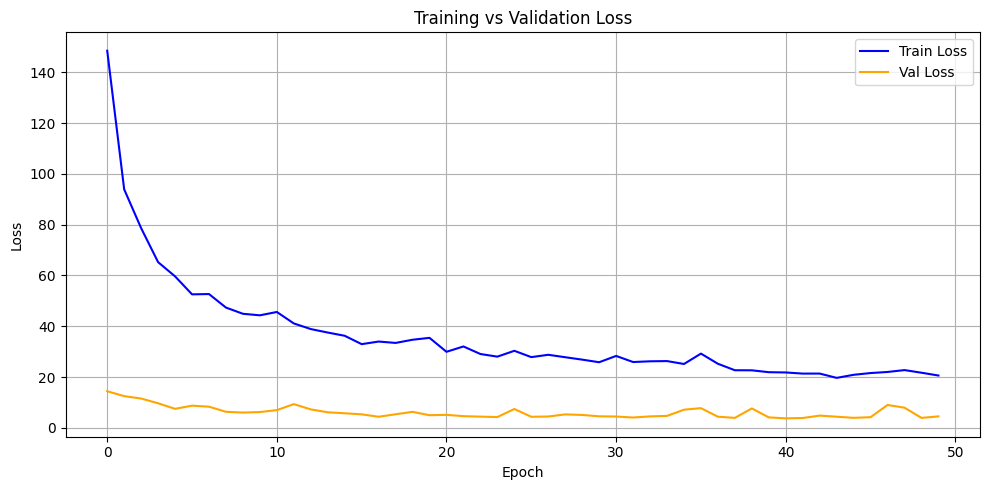

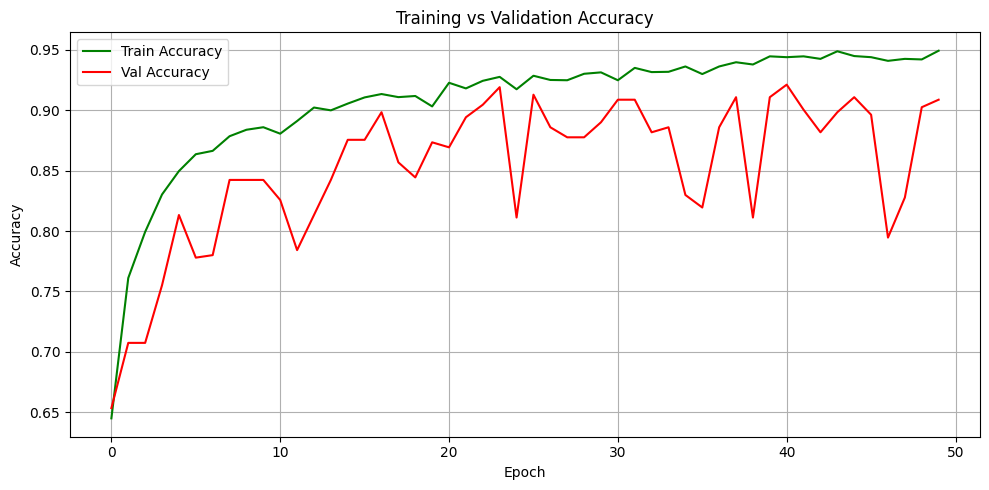

In [23]:
# === PLOT BASELINE TRAINING ===
plot_loss_curve(train_losses_b, val_losses_b)
plot_accuracy_curve(train_accs_b, val_accs_b)


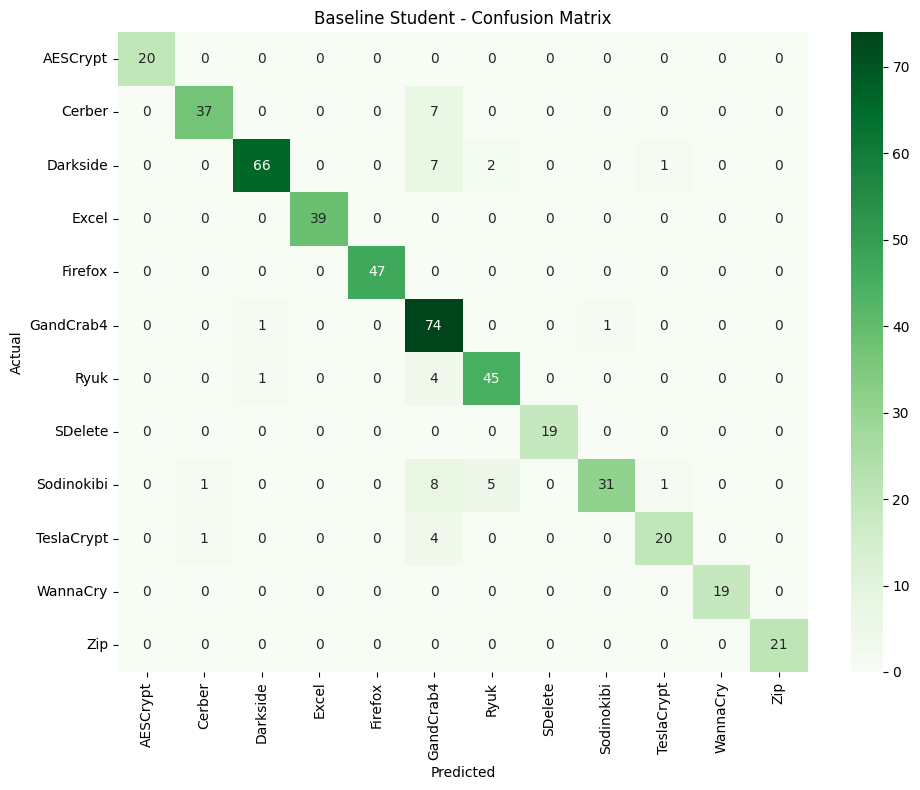


📋 Baseline Classification Report (Student, No KD):

              precision    recall  f1-score   support

    AESCrypt       1.00      1.00      1.00        20
      Cerber       0.95      0.84      0.89        44
    Darkside       0.97      0.87      0.92        76
       Excel       1.00      1.00      1.00        39
     Firefox       1.00      1.00      1.00        47
   GandCrab4       0.71      0.97      0.82        76
        Ryuk       0.87      0.90      0.88        50
     SDelete       1.00      1.00      1.00        19
  Sodinokibi       0.97      0.67      0.79        46
  TeslaCrypt       0.91      0.80      0.85        25
    WannaCry       1.00      1.00      1.00        19
         Zip       1.00      1.00      1.00        21

    accuracy                           0.91       482
   macro avg       0.95      0.92      0.93       482
weighted avg       0.92      0.91      0.91       482

✅ Final Training Accuracy (baseline): 0.9493
✅ Final Validation Accuracy (baseli

In [24]:
student_baseline.eval()
final_preds_b, final_labels_b = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student_baseline(streams)
        preds = torch.argmax(outputs, dim=1)
        final_preds_b.extend(preds.cpu().numpy())
        final_labels_b.extend(labels.cpu().numpy())

# Confusion matrix
cm_b = confusion_matrix(final_labels_b, final_preds_b)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Baseline Student - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Report
print("\n📋 Baseline Classification Report (Student, No KD):\n")
print(classification_report(final_labels_b, final_preds_b, target_names=label_encoder.classes_))
print(f"✅ Final Training Accuracy (baseline): {train_accs_b[-1]:.4f}")
print(f"✅ Final Validation Accuracy (baseline): {val_accs_b[-1]:.4f}")


In [25]:
# Convert test labels back to string for the dataset
y_test_str = label_encoder.inverse_transform(y_test)

# Create test dataset and loader
test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


/tmp/ipykernel_287094/454352857.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("student_baseline.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    1.0000    1.0000        19
      Cerber     1.0000    0.9302    0.9639        43
    Darkside     0.9286    0.8442    0.8844        77
       Excel     1.0000    0.9487    0.9737        39
     Firefox     0.9600    1.0000    0.9796        48
   GandCrab4     0.6796    0.9211    0.7821        76
        Ryuk     0.8511    0.7843    0.8163        51
     SDelete     1.0000    1.0000    1.0000        18
  Sodinokibi     0.9189    0.7234    0.8095        47
  TeslaCrypt     0.9000    0.7200    0.8000        25
    WannaCry     0.9048    1.0000    0.9500        19
         Zip     1.0000    1.0000    1.0000        20

    accuracy                         0.8880       482
   macro avg     0.9286    0.9060    0.9133       482
weighted avg     0.9015    0.8880    0.8894       482



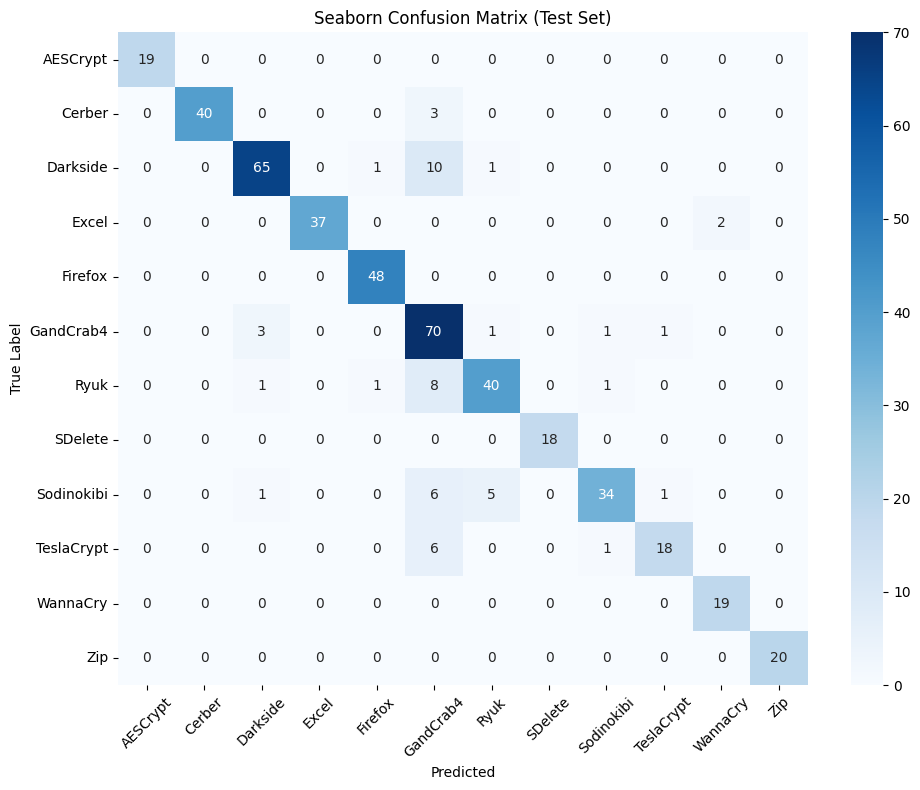

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("student_baseline.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🧠 Multi-class AUC (macro): 0.9951


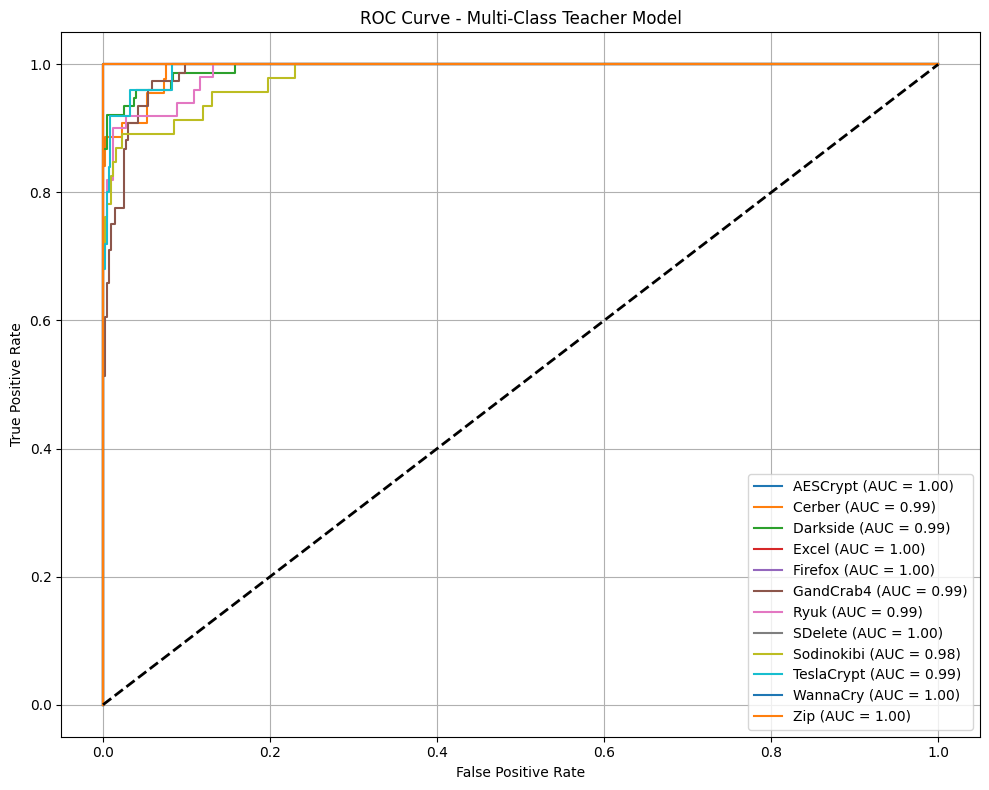

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# === 1. Get predictions on validation set ===
model.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.cpu().numpy()
        outputs = model(streams)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        
        y_probs.extend(probs)
        y_true.extend(labels)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# === 2. Binarize labels for ROC AUC ===
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

# === 3. Compute AUC score (macro-average) ===
auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
print(f"🧠 Multi-class AUC (macro): {auc_macro:.4f}")

# === 4. Plot ROC curves per class ===
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Teacher Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
